In [35]:
import pickle
import pandas as pd

testable_data = pickle.load(open('../testable_data_list.pkl', 'rb'))

simulation_log_fname = f'data/simulation_log.csv'
simulation_log = pd.read_csv(simulation_log_fname)
simulation_pupil_data = simulation_log[["center_x","center_y","diameter_px"]].to_numpy()
print(simulation_pupil_data.shape, 510*len(list(testable_data.keys())))
key_simulation_pupil_data = {}
key_simulation_pupil_size = {}
k = 0
duration_tr = 510
for key in testable_data.keys():
    r = int(key[3][4])
    data = simulation_pupil_data[k*duration_tr:(k+1)*duration_tr,:]
    for i in range(510):
        if data[i, 0] == -1:
            data[i,:] = data[i-1,:]
    key_simulation_pupil_data[key] = data[:,:2]
    key_simulation_pupil_size[key] = data[:,2]
    k += 1

(56610, 3) 56610


In [61]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import eyerec
import mocet
from matplotlib.patches import Ellipse
plt.style.use('default')

subject = 'sub-013'
session = 'ses-07'
task = 'task-mcHERDING'
run = 'run-1'

root = f'../../_DATA/{subject}/{session}'
log_fname = f'{root}/{subject}_{session}_{task}_{run}_recording-eyetracking_physio_log.csv'
data_fname = f'{root}/{subject}_{session}_{task}_{run}_recording-eyetracking_physio_dat.txt'
confounds_fname = f'{root}/{subject}_{session}_{task}_{run}_desc-confounds_timeseries.tsv'

history_fname = f'{root}/{subject}_{session}_{task}_{run}_recording-eyetracking_physio_his.txt'
start, _, _ = mocet.utils.get_avotec_history(history_fname)
    
filename = f'/Volumes/HAZE2/eyetracking/{subject}/{session}/{subject}_{session}_{task}_{run}_recording-eyetracking_physio_mv.avi'
capture = cv2.VideoCapture(filename)
read, frame = capture.read()

target_count = 60*start
count = 1
while read:
    if count > target_count+30:
        video_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        break
    read, frame = capture.read()
    count += 1
print(count, start)

2246 36.928


In [62]:
task_duration = 816
calibration_onsets = [1, 494]
calibration_points = [24, 12]
interval = 1.6
calibration_offset_start = 0.5
calibration_offset_end = -0.5
t_cal = 0

pupil_data, pupil_timestamps, pupil_confidence, pupil_diameter = mocet.utils.clean_avotec_data(log_fname,
                                                                                               data_fname,
                                                                                               start=start,
                                                                                               duration=task_duration)
offset = calibration_onsets[t_cal]
calibration_pupils = []
for i in np.arange(calibration_points[t_cal]):
    start_time = (offset + i) * interval + calibration_offset_start
    end_time = (offset + i + 1) * interval + calibration_offset_end
    log_effective = np.logical_and(pupil_timestamps >= start_time * 1000, pupil_timestamps < end_time * 1000)
    calibration_pupils.append([np.nanmean(pupil_data[log_effective, 0]),
                               np.nanmean(pupil_data[log_effective, 1])])
calibration_pupils = np.array(calibration_pupils).reshape(2, 12, 2).mean(axis=0)

basis = np.load("data/basis.npy")
basis_params = np.load("data/basis_params.npy")
basis_similarity = []
for i in range(len(basis)):
    basis_similarity.append(np.mean(np.sqrt(np.sum((basis[i] - calibration_pupils)**2, axis=-1))))
basis_idx = np.argmin(basis_similarity)
print(subject, session, task, run, basis_idx, basis_params[basis_idx])

sub-013 ses-07 task-mcHERDING run-1 10229 [-2.18166156e-02  0.00000000e+00  2.50000000e-01 -2.50000000e+01]


([], [])

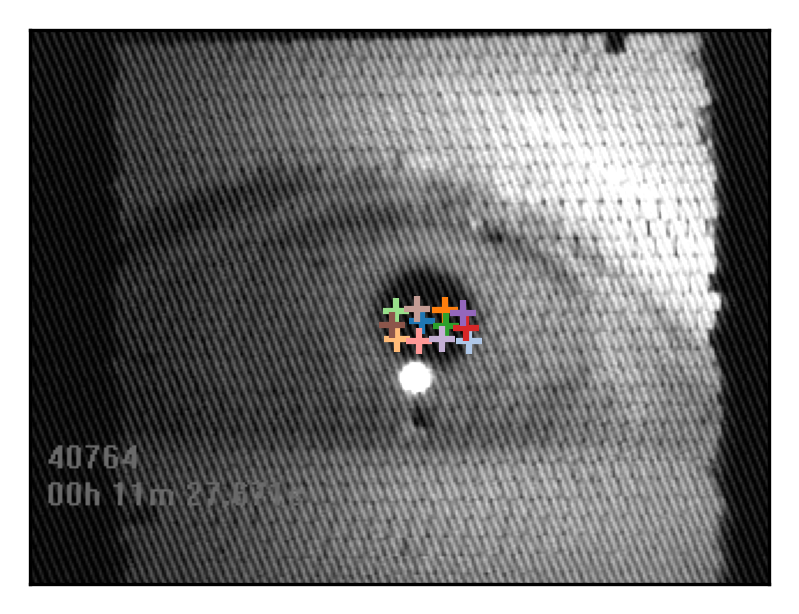

In [63]:
import seaborn as sns

pupil_colors = sns.color_palette("tab20", 12)
plt.figure(dpi=300, figsize=(3.2, 2.4))
plt.imshow(np.array(video_frame.mean(-1))/255, vmin=0.0, vmax=0.8, cmap='gray')

for i in range(12):
    #plt.scatter(calibration_pupils[i, 0], calibration_pupils[i, 1], color='#33db67', marker='+', s=40)
    plt.scatter(calibration_pupils[i, 0], calibration_pupils[i, 1], color=pupil_colors[i], marker='+', s=40)
plt.xticks([])
plt.yticks([])

In [64]:
from PIL import Image

basis_parameter = basis_params[basis_idx]

plt.style.use('default')
screen = mocet.simulation.Screen()
gaze_target = screen.get_target(np.array([800,500]))

head = mocet.simulation.Head()
head.set_gaze(gaze=gaze_target)
head.add_eyeball_left()
head.add_eyeball_right()

camera_position = (-0.035, basis_parameter[2], 0.0037)
camera_direction = (basis_parameter[0], -1, basis_parameter[1])
camera_tilt = [np.sin(np.deg2rad(basis_parameter[3])), 0, np.cos(np.deg2rad(basis_parameter[3]))]

scene = mocet.simulation.Scene(width=128*4, height=96*4, objects=head.objects)
scene.add_camera(camera_position=camera_position, camera_direction=camera_direction, camera_tilt=camera_tilt)
scene.add_light(light_position=(0, 1.0, 1.0), light_color=(1, 1, 1))
scene.render()

image = np.flip(scene.image, axis=1)
image = 255.0 * image
image = image.astype(np.uint8)
im = Image.fromarray(image).resize((320, 240), Image.NEAREST)
        

('sub-013', 'ses-07', 'task-mcHERDING', 'run-1')


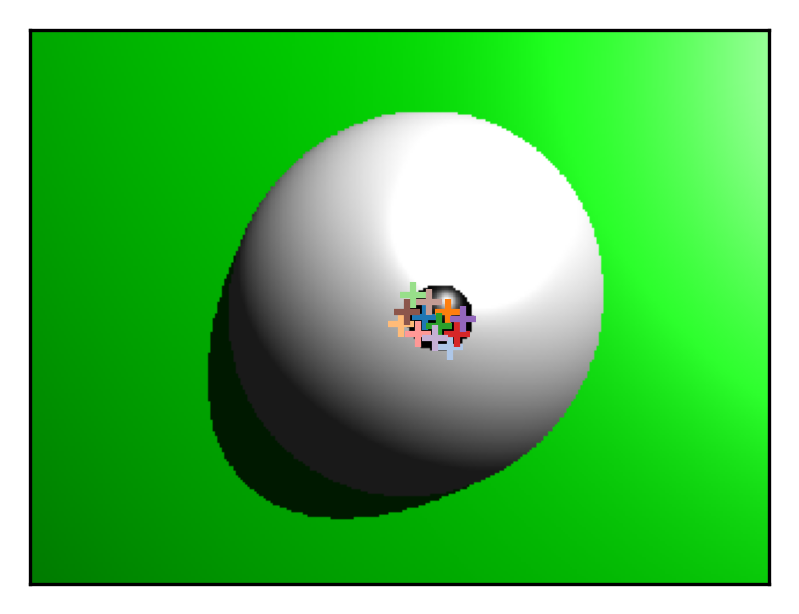

In [65]:
key = (subject, session, task, run)
print(key)
pupil_data = key_simulation_pupil_data[key]
t_cal = 0
offset = 1
calibration_pupils = []
for i in np.arange(24):
    start = (offset+i)
    end = (offset+i+1)
    calibration_pupils.append([np.nanmean(pupil_data[start:end,0]),
                               np.nanmean(pupil_data[start:end,1])])
calibration_pupils = np.array(calibration_pupils)
calibration_pupils = (calibration_pupils[:12,:] + calibration_pupils[12:,:]) / 2

plt.figure(dpi=300, figsize=(3.2, 2.4))
plt.imshow(im)
for i in range(12):
    #plt.scatter(calibration_pupils[i, 0], calibration_pupils[i, 1], color='#33db67', marker='+', s=40)
    plt.scatter(calibration_pupils[i, 0], calibration_pupils[i, 1], color=pupil_colors[i], marker='+', s=40)
plt.xticks([])
plt.yticks([])
plt.show()